In [1]:
import pandas as pd
ds = pd.read_csv(r"C:\Users\agraw\OneDrive\Desktop\species.zip")
ds.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [2]:
ds["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [3]:
ds["Species"].info

<bound method Series.info of 0         Iris-setosa
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
            ...      
145    Iris-virginica
146    Iris-virginica
147    Iris-virginica
148    Iris-virginica
149    Iris-virginica
Name: Species, Length: 150, dtype: object>

In [4]:
ds["Species"] = ds["Species"].replace({"Iris-versicolor" : "2", "Iris-virginica" : "3", "Iris-setosa" : "1" })
ds.head(100)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,1
1,2,4.9,3.0,1.4,0.2,1
2,3,4.7,3.2,1.3,0.2,1
3,4,4.6,3.1,1.5,0.2,1
4,5,5.0,3.6,1.4,0.2,1
...,...,...,...,...,...,...
95,96,5.7,3.0,4.2,1.2,2
96,97,5.7,2.9,4.2,1.3,2
97,98,6.2,2.9,4.3,1.3,2
98,99,5.1,2.5,3.0,1.1,2


In [5]:
ds["Species"] = ds["Species"].astype("int64")
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    int64  
dtypes: float64(4), int64(2)
memory usage: 7.2 KB


In [6]:
ds[["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]] = ds[["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]].astype("int64")
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Id             150 non-null    int64
 1   SepalLengthCm  150 non-null    int64
 2   SepalWidthCm   150 non-null    int64
 3   PetalLengthCm  150 non-null    int64
 4   PetalWidthCm   150 non-null    int64
 5   Species        150 non-null    int64
dtypes: int64(6)
memory usage: 7.2 KB


# Testing and Splitting

In [7]:
input = ds.iloc[:,:-1]
output = ds["Species"]
input.head() 

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,1,5,3,1,0
1,2,4,3,1,0
2,3,4,3,1,0
3,4,4,3,1,0
4,5,5,3,1,0


In [8]:
output.head()

0    1
1    1
2    1
3    1
4    1
Name: Species, dtype: int64

In [9]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(input, output, test_size = 0.25)

In [10]:
ds.shape, x_train.shape, x_test.shape, y_train.shape, y_test.shape

((150, 6), (112, 5), (38, 5), (112,), (38,))

# Linear Regression

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
ds = pd.read_csv(r"C:\Users\agraw\OneDrive\Desktop\archive (1).zip")
ds.isnull().sum()

cgpa       0
package    0
dtype: int64

In [12]:
ds.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


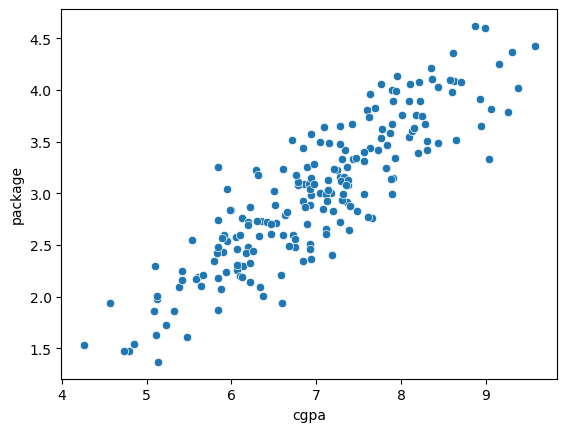

In [13]:
sns.scatterplot(x = "cgpa", y = "package", data = ds)
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
# splitting the data as input and output
x = ds[["cgpa"]]
y = ds["package"]
x.ndim, y.ndim               
# input data must be in 2 dimension
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.30, random_state= 40)

In [15]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [16]:
# fit function calculate coefficient and intercept and find best fit line
lr.fit(x_train, y_train)
lr.predict([[6.89]])

C:\Users\agraw\Downloads\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([2.97091408])

In [17]:
# checking accuracy of prediction
lr.score(x_test, y_test)
# 75% accuracy

0.7519705464243485

In [18]:
# coefficient is value of m, intercept is c inequation (y = m*x + c)
print(lr.coef_, lr.intercept_)

[0.57954434] -1.0221464322830163


In [19]:
#y = 0.57954434*x -1.0221464322830163
# = = 6.89
y = 0.57954434*6.89 -1.0221464322830163
print(y)
# predict function do this calculation after the performance of fit function

2.9709140703169834


# Multilinear Regression

In [20]:
# equation : y = m1*x1 + m2*x2 +...+ c ; equation of plane
ds = pd.read_csv(r"C:\Users\agraw\OneDrive\Desktop\age, salary, experience dataset.zip")
ds.head()

,YearsExperience,Age,Salary
0,1.1,21.0,39343
1,1.3,21.5,46205
2,1.5,21.7,37731
3,2.0,22.0,43525
4,2.2,22.2,39891


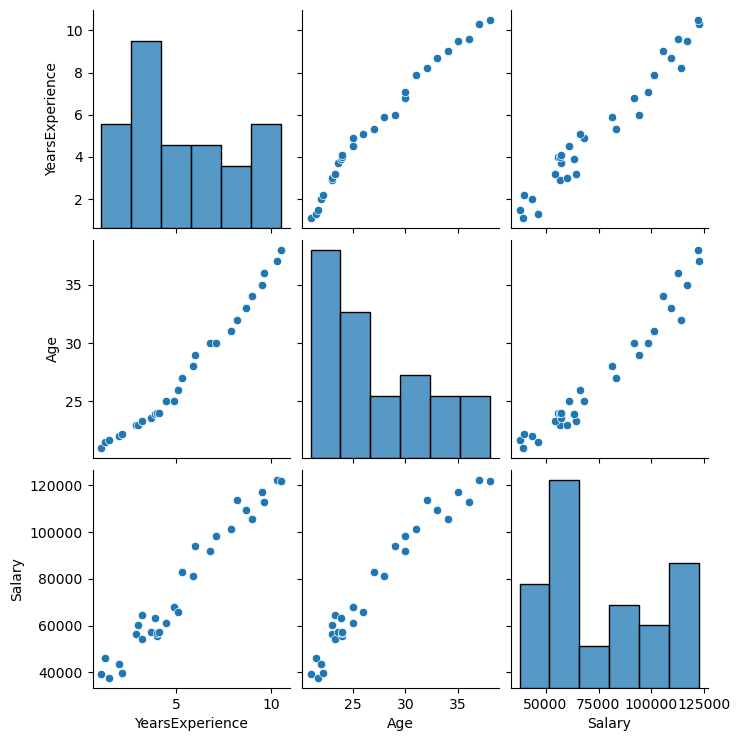

In [21]:
# checking for linearity
sns.pairplot(data = ds)
plt.show()

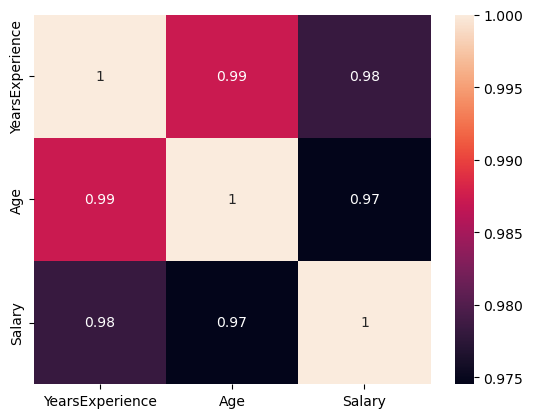

In [22]:
sns.heatmap(data = ds.corr(), annot = True)
plt.show()

In [23]:
from sklearn.model_selection import train_test_split
# splitting the data as input and outpu
x = ds[["YearsExperience", "Age"]]
y = ds["Salary"]
x.ndim, y.ndim               
# input data must be in 2 dimension
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.30, random_state= 40)

In [24]:
# fit will calculate m1, m2, c
lr.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [25]:
# predict will calculate : m1*x1 + m2*x2 + c
print(lr.predict([[1.1, 21.0]]))

[39249.6900281]


C:\Users\agraw\Downloads\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [26]:
lr.score(x_test, y_test)
# 93% accuracy

0.938619928117691

In [27]:
print(lr.coef_, lr.intercept_)

[7291.95422727 1127.914467  ] 7542.336571156498


# Polynomial Regression 

In [28]:
# equation : y = a0 + a1*x + a2*x^2 +...+ an*x^n
ds = pd.read_csv(r"C:\Users\agraw\OneDrive\Desktop\level and salary dataset.zip")
ds.drop(columns = "Position", inplace = True)
ds.head()

,Level,Salary
0,1,45000
1,2,50000
2,3,60000
3,4,80000
4,5,110000


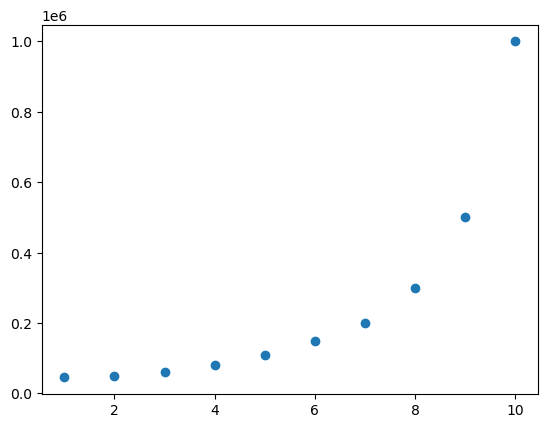

In [29]:
plt.scatter(ds["Level"], ds["Salary"])
plt.show()

In [30]:
ds.corr()

,Level,Salary
Level,1.000000,0.817949
Salary,0.817949,1.000000


In [31]:
x = ds[["Level"]]
y = ds["Salary"]

In [32]:
from sklearn.preprocessing import PolynomialFeatures
pf = PolynomialFeatures(degree = 2)
pf.fit(x)
x = pf.transform(x)

In [33]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.30, random_state= 42)
from sklearn.linear_model import LinearRegression
l = LinearRegression()
l.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [34]:
l.score(x_test, y_test)

0.7896604512664295

In [35]:
test = pf.transform([[2]])
print(l.predict(test))

[37834.14365654]


C:\Users\agraw\Downloads\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
